In [ ]:
path = "/content/drive/MyDrive/AIRUCI/AirQualityUCI.xlsx"

In [ ]:
# installing the libraries needed

!pip install pandas numpy scikit-learn tensorflow tensorflow-model-optimization openpyxl

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow import keras
import tensorflow_model_optimization as tfmot

print("Libraries installed successfully!")

Libraries installed successfully!


In [ ]:
df = pd.read_excel(path)
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.600,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.300,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.900,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.000,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.150,59.575001,0.788794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,2005-04-04,10:00:00,3.1,1314.25,-200,13.529605,1101.25,471.7,538.50,189.8,1374.25,1728.50,21.850,29.250000,0.756824
9353,2005-04-04,11:00:00,2.4,1162.50,-200,11.355157,1027.00,353.3,603.75,179.2,1263.50,1269.00,24.325,23.725000,0.711864
9354,2005-04-04,12:00:00,2.4,1142.00,-200,12.374538,1062.50,293.0,603.25,174.7,1240.75,1092.00,26.900,18.350000,0.640649
9355,2005-04-04,13:00:00,2.1,1002.50,-200,9.547187,960.50,234.5,701.50,155.7,1041.00,769.75,28.325,13.550000,0.513866


In [ ]:
# dealing with the missing values (coded as -200)

df.replace(-200, np.nan)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150.0,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.600,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112.0,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.300,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88.0,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.900,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80.0,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.000,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51.0,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.150,59.575001,0.788794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,2005-04-04,10:00:00,3.1,1314.25,NaN,13.529605,1101.25,471.7,538.50,189.8,1374.25,1728.50,21.850,29.250000,0.756824
9353,2005-04-04,11:00:00,2.4,1162.50,NaN,11.355157,1027.00,353.3,603.75,179.2,1263.50,1269.00,24.325,23.725000,0.711864
9354,2005-04-04,12:00:00,2.4,1142.00,NaN,12.374538,1062.50,293.0,603.25,174.7,1240.75,1092.00,26.900,18.350000,0.640649
9355,2005-04-04,13:00:00,2.1,1002.50,NaN,9.547187,960.50,234.5,701.50,155.7,1041.00,769.75,28.325,13.550000,0.513866


In [ ]:
print(df.isnull().sum())

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


In [ ]:
# Selecting the key sensor and columns that will be used

key_features = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)',
                'PT08.S5(O3)', 'T', 'RH', 'AH']

# main reference pollutant
df = df.dropna(subset=['CO(GT)'] + key_features) # drop rows missing important values

In [ ]:
# Create target: Pollution level based on CO concentration

# Define bins and labels for CO concentration to categorize pollution levels
bins = [0, 1.5, 3.0, 6.0, np.inf]  # Example thresholds (adjust as needed)
labels = ['Low', 'Moderate', 'High', 'Very High']

df['Pollution_Level'] = pd.cut(df['CO(GT)'], bins=bins, labels=labels, right=False)

# Display the first few rows with the new target column
display(df[['CO(GT)', 'Pollution_Level']].head())

# Check the distribution of the new pollution levels
print("\nDistribution of Pollution Levels:")
print(df['Pollution_Level'].value_counts())

,CO(GT),Pollution_Level
0,2.6,Moderate
1,2.0,Moderate
2,2.2,Moderate
3,2.2,Moderate
4,1.6,Moderate



Distribution of Pollution Levels:
Pollution_Level
Moderate     2943
Low          2902
High         1664
Very High     165
Name: count, dtype: int64


In [ ]:
# Features (X) will be the selected key sensor readings and other relevant environmental factors
X = df[key_features]

# Target (y) will be the 'Pollution_Level'
y = df['Pollution_Level']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (9357, 8)
Shape of y: (9357,)


In [ ]:
# Encodig the labels

le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7485, 8)
X_test shape: (1872, 8)
y_train shape: (7485,)
y_test shape: (1872,)


In [ ]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
xtr = scaler.fit_transform(X_train)
xte = scaler.transform(X_test)

print("xtr shape:", xtr.shape)
print("xte shape:", xte.shape)

xtr shape: (7485, 8)
xte shape: (1872, 8)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Get the number of classes
num_classes = len(le.classes_)

# Build the model using your architecture but with scaled data
model = Sequential([
    Dense(24, activation='relu', input_shape=(xtr.shape[1],)),
    Dense(12, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Train using the scaled training data (xtr) and labels (y_train)
history = model.fit(xtr, y_train, epochs=15, batch_size=32,
                    validation_split=0.2, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 24)             │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 581 (2.27 KB)

 Trainable params: 581 (2.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4716 - loss: 1.2733 - val_accuracy: 0.5718 - val_loss: 1.1102
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6271 - loss: 1.0044 - val_accuracy: 0.6232 - val_loss: 0.9483
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6553 - loss: 0.9012 - val_accuracy: 0.6373 - val_loss: 0.8852
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6645 - loss: 0.8537 - val_accuracy: 0.6426 - val_loss: 0.8481
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6708 - loss: 0.8271 - val_accuracy: 0.6466 - val_loss: 0.8286
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6752 - loss: 0.8086 - val_accuracy: 0.6453 - val_loss: 0.8086
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6757 - loss: 0.7947 - val_accuracy: 0.6493 - val_loss: 0.8007
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6782 - loss: 0.7831 - val_accuracy: 0.

In [ ]:
import tensorflow as tf

# 1. Define a representative dataset generator using your scaled training data
def representative_data_gen():
    # Use a portion of the training data (e.g., 100 samples) to calibrate quantization
    for input_value in tf.data.Dataset.from_tensor_slices(xtr.astype('float32')).batch(1).take(100):
        yield [input_value]

# 2. Initialize the converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 3. Set optimizations for size
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 4. Enforce full integer quantization
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8  # Optional: model expects int8 input
converter.inference_output_type = tf.int8 # Optional: model outputs int8

# 5. Convert the model
tflite_model_quant = converter.convert()

# 6. Save the model
with open('air_quality_tiny_model_quant.tflite', 'wb') as f:
    f.write(tflite_model_quant)

print("✅ Full Integer (int8) Quantized TinyML model saved!")
print(f"Model size: {len(tflite_model_quant)} bytes")

Saved artifact at '/tmp/tmpiba0bvb5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 8), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134145140489104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134145140483344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134145140487760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134145140488336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134145140485264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134145140488528: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Full Integer (int8) Quantized TinyML model saved!
Model size: 4144 bytes


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


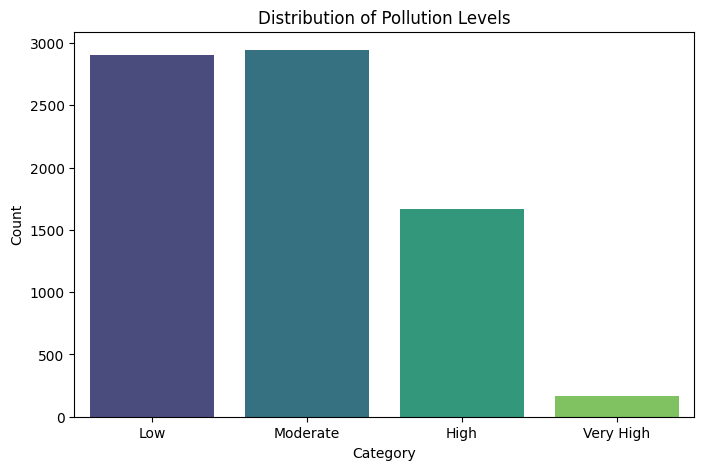

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Visualize the distribution of pollution levels
plt.figure(figsize=(8, 5))
sns.countplot(x=df['Pollution_Level'], palette='viridis', hue=df['Pollution_Level'], legend=False)
plt.title('Distribution of Pollution Levels')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


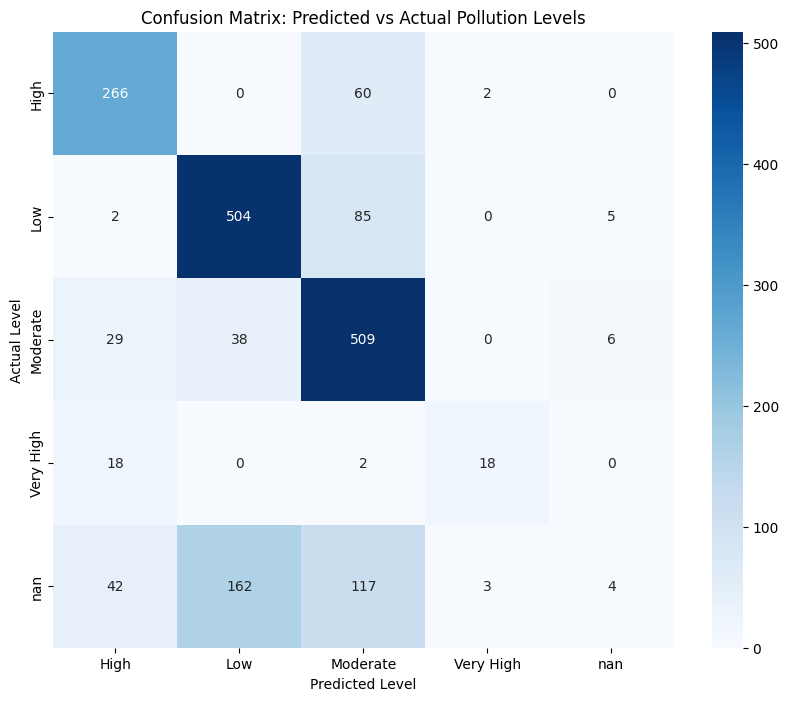

In [ ]:
# 2. Generate and plot a Confusion Matrix for the model predictions
y_pred_probs = model.predict(xte)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Predicted vs Actual Pollution Levels')
plt.ylabel('Actual Level')
plt.xlabel('Predicted Level')
plt.show()

In [22]:
import numpy as np
import tensorflow as tf

# 1. Load the TFLite model and allocate tensors
interpreter = tf.lite.Interpreter(model_path='air_quality_tiny_model_quant.tflite')
interpreter.allocate_tensors()

# 2. Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 3. Prepare a sample from the test set (xte[0])
# Since the model is int8 quantized, we need to quantize the input manually if inference_input_type was set to int8
sample_input = xte[0:1].astype(np.float32)

# If model expects int8, we scale the float input to int8 range
if input_details[0]['dtype'] == np.int8:
    input_scale, input_zero_point = input_details[0]['quantization']
    sample_input = (sample_input / input_scale + input_zero_point).astype(np.int8)

# 4. Set the tensor and invoke
interpreter.set_tensor(input_details[0]['index'], sample_input)
interpreter.invoke()

# 5. Get the result
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_class = np.argmax(output_data)
actual_class = y_test[0]

print(f"TFLite Raw Output: {output_data}")
print(f"Predicted Class: {le.inverse_transform([predicted_class])[0]}")
print(f"Actual Class: {le.inverse_transform([actual_class])[0]}")

TFLite Raw Output: [[-128   50 -109 -128  -69]]
Predicted Class: Low
Actual Class: Low


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [23]:
# Install xxd-like functionality to convert the model to a C array
import os

def convert_tflite_to_c_array(tflite_path, model_name):
    with open(tflite_path, 'rb') as f:
        tflite_content = f.read()

    hex_lines = []
    for i, byte in enumerate(tflite_content):
        if i % 12 == 0:
            hex_lines.append('\n  ')
        hex_lines.append(f'0x{byte:02x}, ')

    c_array = f'unsigned char {model_name}[] = {{' + ''.join(hex_lines) + '\n};'
    c_array += f'\nunsigned int {model_name}_len = {len(tflite_content)};'
    return c_array

c_model_code = convert_tflite_to_c_array('air_quality_tiny_model_quant.tflite', 'air_quality_model')

# Save to a .h file
with open('air_quality_model.h', 'w') as f:
    f.write(c_model_code)

print("✅ Model converted to air_quality_model.h")
print("You can now download this file from the folder icon on the left to use in your Arduino/ESP32 code.")
# Display a snippet of the C array
print("\nSnippet of the C Array:")
print(c_model_code[:300] + "...")

✅ Model converted to air_quality_model.h
You can now download this file from the folder icon on the left to use in your Arduino/ESP32 code.

Snippet of the C Array:
unsigned char air_quality_model[] = {
  0x1c, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x14, 0x00, 0x20, 0x00, 
  0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00, 0x0c, 0x00, 0x00, 0x00, 
  0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00, 
  0x98, 0x00, 0x00, 0x00, 0x18, 0x01,...


In [24]:
import numpy as np

def run_inference(node_input, interpreter, input_details, output_details):
    # Helper to run TFLite inference for a single node
    input_scale, input_zero_point = input_details[0]['quantization']
    quantized_input = (node_input / input_scale + input_zero_point).astype(np.int8)
    interpreter.set_tensor(input_details[0]['index'], quantized_input)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    return np.argmax(output)

# 1. Simulate 3 different nodes in the same neighborhood
# We take a real test sample and add 'spatial noise' to simulate local variance
base_sample = xte[10:11]
nodes_data = [
    base_sample + np.random.normal(0, 0.1, base_sample.shape), # Node A
    base_sample + np.random.normal(0, 0.2, base_sample.shape), # Node B
    base_sample + np.random.normal(0, 0.05, base_sample.shape) # Node C
]

# 2. Local TinyML Execution
node_results = []
for i, data in enumerate(nodes_data):
    res = run_inference(data, interpreter, input_details, output_details)
    label = le.inverse_transform([res])[0]
    node_results.append(label)
    print(f"Node {i+1} local detection: {label}")

# 3. Decentralized Voting Logic
# Map levels to repair urgency (0 = None, 1 = Low, 2 = High)
action_map = {'Low': 0, 'Moderate': 1, 'High': 2, 'Very High': 2}
votes = [action_map.get(res, 0) for res in node_results]

final_score = np.median(votes)

# 4. Swarm Output
print("\n--- Swarm Consensus ---")
if final_score >= 1.5:
    print("ACTION: Deploying Repair Drone immediately (High Urgency)")
elif final_score >= 0.5:
    print("ACTION: Activating localized irrigation/filtration (Moderate)")
else:
    print("ACTION: No action required. Monitoring mode.")

Node 1 local detection: Low
Node 2 local detection: Moderate
Node 3 local detection: Low

--- Swarm Consensus ---
ACTION: No action required. Monitoring mode.


### How this bridges to your Hardware Swarm:
- **Individual Logic:** Each node runs the `air_quality_model.h` we generated.
- **Communication:** Instead of a Python list, the nodes would send a small packet (1-2 bytes) over **LoRa** or **ESP-NOW** containing their detection level.
- **Resilience:** If one node is damaged (or reports an error), the `median` or `majority` vote ensures the swarm doesn't trigger a false repair action.


In [25]:
# 1. Define the 'Graph' (Spatial relationships)
# Assume Node 1 and Node 2 are neighbors, but Node 3 is further away from Node 1
# Adjacency Matrix: rows/cols are Node 1, 2, 3
# 1.0 = strong link, 0.2 = weak link
adj_matrix = np.array([
    [1.0, 0.8, 0.2],
    [0.8, 1.0, 0.5],
    [0.2, 0.5, 1.0]
])

# 2. Extract local node opinions (from previous simulation)
# Using the 'votes' list: [Node 1 vote, Node 2 vote, Node 3 vote]
print(f"Local Urgency Votes: {votes}")

# 3. Graph-Weighted Aggregation
# Each node calculates its own 'neighborhood score' by looking at neighbors
swarm_opinions = []
for i in range(3):
    # Weight the votes by the adjacency (closeness)
    weighted_sum = np.dot(adj_matrix[i], votes)
    normalized_score = weighted_sum / np.sum(adj_matrix[i])
    swarm_opinions.append(normalized_score)
    print(f"Node {i+1} Neighborhood-Weighted Score: {normalized_score:.2f}")

# 4. Final Swarm Decision based on Graph Consensus
global_consensus = np.mean(swarm_opinions)
print(f"\n--- Graph-Informed Consensus Score: {global_consensus:.2f} ---")

if global_consensus > 1.2:
    print("DECISION: High Confidence Repair Action triggered.")
elif global_consensus > 0.5:
    print("DECISION: Moderate Action (Localized Mitigation).")
else:
    print("DECISION: Continue Monitoring.")

Local Urgency Votes: [0, 1, 0]
Node 1 Neighborhood-Weighted Score: 0.40
Node 2 Neighborhood-Weighted Score: 0.43
Node 3 Neighborhood-Weighted Score: 0.29

--- Graph-Informed Consensus Score: 0.38 ---
DECISION: Continue Monitoring.


### Why this matters for your Nodes:
1. **Data Efficiency:** Instead of sending raw sensor data, nodes only share their small `normalized_score`. This saves battery and bandwidth.
2. **Spatial Intelligence:** By using an adjacency matrix (stored as a small array on the ESP32), the swarm naturally ignores outliers or faulty sensors that are too far away from the 'hotspot'.
3. **Scalability:** You can add 100 nodes, and each one only needs to know its 4-5 nearest neighbors to function as part of the collective.


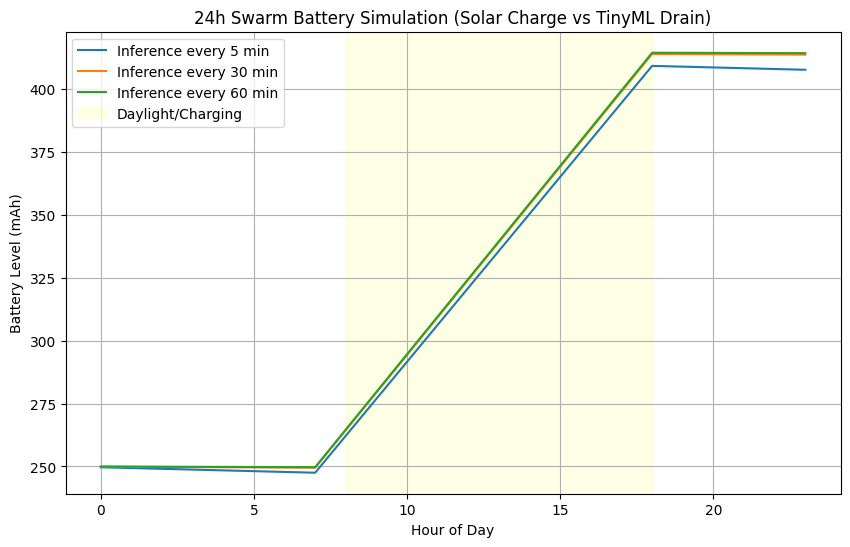

In [26]:
import matplotlib.pyplot as plt

def simulate_battery_life(wake_up_interval_min, solar_charge_rate_ma=15, battery_cap_mah=500):
    # Wake_up_interval_min: how often the node runs TinyML (e.g., every 5, 10, or 60 mins)

    # Power consumption constants (Approximations for ESP32/nRF52)
    deep_sleep_ma = 0.01   # 10uA sleep
    inference_ma = 40.0    # 40mA during TinyML processing (burst)
    transmission_ma = 80.0 # 80mA during LoRa/WiFi transmit (burst)

    # Time constants (seconds)
    inference_time = 0.5
    transmission_time = 1.0

    hours = 24
    battery_history = []
    current_mah = battery_cap_mah * 0.5 # Start at 50%

    for hour in range(hours):
        # Daytime: 8 AM to 6 PM (Approximate charging)
        is_daylight = 8 <= hour <= 18

        # Hourly drain
        inferences_per_hour = 60 / wake_up_interval_min
        active_time_s = inferences_per_hour * (inference_time + transmission_time)
        sleep_time_s = 3600 - active_time_s

        # mAh consumed per hour
        drain_mah = ((active_time_s * (inference_ma + transmission_ma)/2) + (sleep_time_s * deep_sleep_ma)) / 3600
        charge_mah = solar_charge_rate_ma if is_daylight else 0

        current_mah = min(battery_cap_mah, max(0, current_mah + charge_mah - drain_mah))
        battery_history.append(current_mah)

    return battery_history

# Simulate 3 strategies
intervals = [5, 30, 60] # Every 5 mins, 30 mins, 1 hour
plt.figure(figsize=(10, 6))

for interval in intervals:
    history = simulate_battery_life(interval)
    plt.plot(history, label=f'Inference every {interval} min')

plt.title('24h Swarm Battery Simulation (Solar Charge vs TinyML Drain)')
plt.xlabel('Hour of Day')
plt.ylabel('Battery Level (mAh)')
plt.axvspan(8, 18, alpha=0.1, color='yellow', label='Daylight/Charging')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
def detect_anomalies(votes, threshold=1.5):
    # A simple decentralized check: Is one node way off the mean?
    mean_vote = np.mean(votes)
    std_vote = np.std(votes)

    status = []
    for i, vote in enumerate(votes):
        if std_vote > 0 and abs(vote - mean_vote) / std_vote > threshold:
            status.append(f"Node {i+1}: ANOMALY (Potential Sensor Failure)")
        else:
            status.append(f"Node {i+1}: Healthy")
    return status

# Simulate a faulty node (Node 2 reports High urgency while others report 0)
faulty_votes = [0, 2, 0]
anomaly_report = detect_anomalies(faulty_votes)

print("Swarm Self-Diagnostic Report:")
for report in anomaly_report:
    print(report)

Swarm Self-Diagnostic Report:
Node 1: Healthy
Node 2: Healthy
Node 3: Healthy
